<a href="https://colab.research.google.com/github/DharshiniJ-hub/Gold-price-prediction/blob/main/FINALMINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

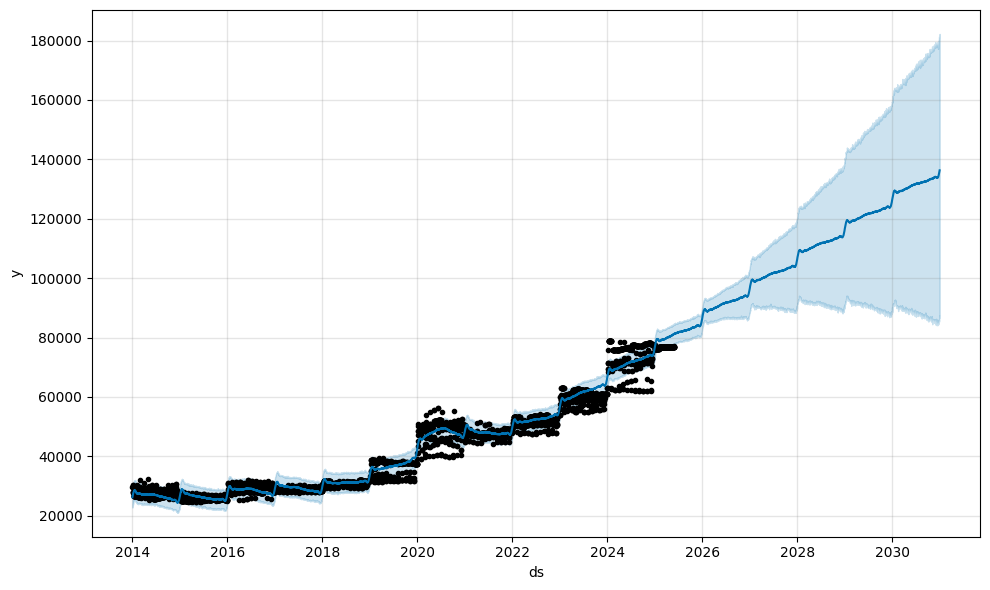

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3832
[LightGBM] [Info] Number of data points in the train set: 3930, number of used features: 17
[LightGBM] [Info] Start training from score 41971.618575
GradientBoosting RMSE 463.6409339993953 MAE 375.8345641863722 R2 0.780238261762561
LightGBM RMSE 399.4250318670166 MAE 214.7788868188192 R2 0.8368980721129909
XGBoost RMSE 608.6442199125053 MAE 548.3557725694444 R2 0.6212823536783454
Best ML: LightGBM


In [1]:
import pandas as pd, numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet   # pip install prophet

# 1) Load Data
df = pd.read_csv("Gold Price (3).csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df[['Date','Price']].rename(columns={'Date':'ds','Price':'y'}).dropna().sort_values('ds')
df = df.set_index('ds').asfreq('D')
df['y'] = df['y'].ffill()
df = df.reset_index()

# 2) Prophet Forecast
m = Prophet(daily_seasonality=True, yearly_seasonality=True)
m.fit(df[['ds','y']])
future = m.make_future_dataframe(periods=(pd.to_datetime('2030-12-31') - df['ds'].max()).days)
forecast_prophet = m.predict(future)
forecast_prophet[['ds','yhat']].to_csv('prophet_forecast_to_2030.csv', index=False)
m.plot(forecast_prophet); plt.show()

# 3) Feature Creation
def create_features(df):
    df2 = df.copy()
    df2['dayofweek'] = df2['ds'].dt.dayofweek
    df2['month'] = df2['ds'].dt.month
    df2['dayofyear'] = df2['ds'].dt.dayofyear
    df2['pct_change'] = df2['y'].pct_change().fillna(0)
    lags = [1,2,3,7,14,30,60]
    for l in lags:
        df2[f'lag_{l}'] = df2['y'].shift(l)
    for w in [7,14,30]:
        df2[f'roll_mean_{w}'] = df2['y'].shift(1).rolling(w, min_periods=1).mean()
        df2[f'roll_std_{w}']  = df2['y'].shift(1).rolling(w, min_periods=1).std().fillna(0)
    return df2.dropna().reset_index(drop=True)

df_feat = create_features(df)
test_days = 180
train = df_feat.iloc[:-test_days]
test = df_feat.iloc[-test_days:]
X_cols = [c for c in df_feat.columns if c not in ['ds','y']]

X_train, y_train = train[X_cols], train['y']
X_test, y_test   = test[X_cols], test['y']

# 4) Models (Gradient Boosting, LightGBM, XGBoost)
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

xgbm = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=4
)

# Fit all models
gbr.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
xgbm.fit(X_train, y_train)

# 5) Evaluate
for name, mdl in [('GradientBoosting', gbr), ('LightGBM', lgbm), ('XGBoost', xgbm)]:
    ypred = mdl.predict(X_test)
    print(name,
          "RMSE", np.sqrt(mean_squared_error(y_test, ypred)),
          "MAE", mean_absolute_error(y_test, ypred),
          "R2", r2_score(y_test, ypred))

# 6) Forecast to 2030 with best ML model by RMSE
best = min(
    [('GradientBoosting', gbr), ('LightGBM', lgbm), ('XGBoost', xgbm)],
    key=lambda t: np.sqrt(mean_squared_error(y_test, t[1].predict(X_test)))
)
best_name, best_model = best
print("Best ML:", best_name)


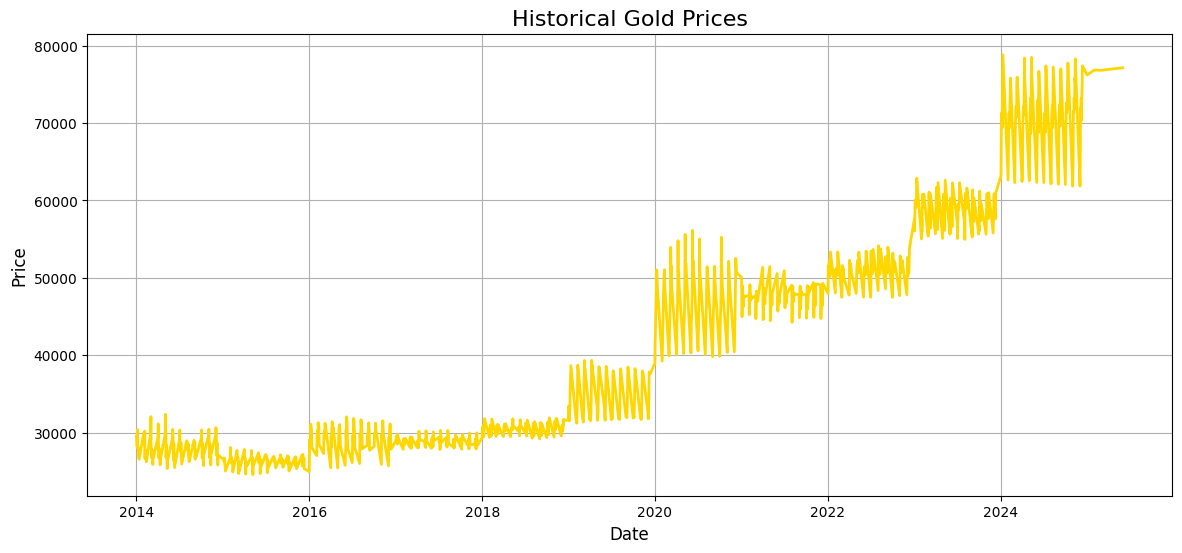

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#  Load the gold price dataset
df = pd.read_csv("Gold Price (3).csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df[['Date','Price']].dropna().sort_values('Date')
df = df.rename(columns={'Date':'ds','Price':'y'})

# Plot historical gold prices
plt.figure(figsize=(14,6))
plt.plot(df['ds'], df['y'], color='gold', linewidth=2)
plt.title('Historical Gold Prices', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True)
plt.show()

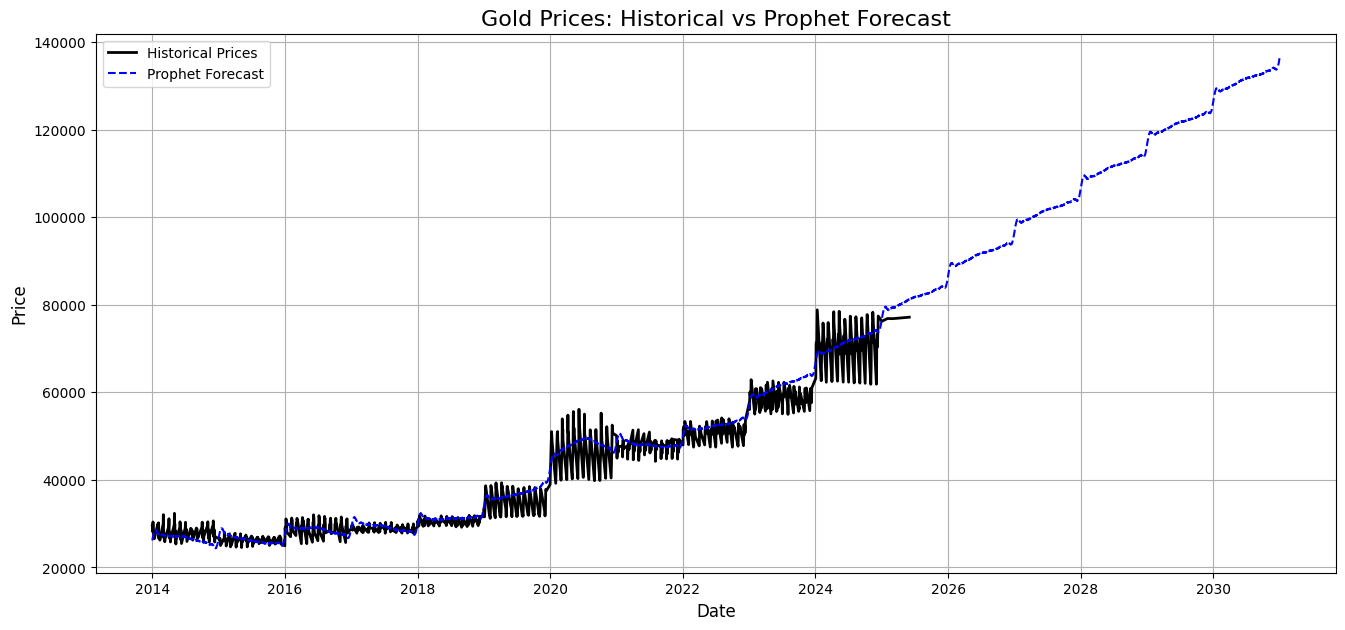

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load historical data
df = pd.read_csv("Gold Price (3).csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df[['Date','Price']].dropna().sort_values('Date')
df = df.rename(columns={'Date':'ds','Price':'y'})

#  Load Prophet forecast
prophet_forecast = pd.read_csv('prophet_forecast_to_2030.csv', parse_dates=['ds'])

#  Plot
plt.figure(figsize=(16,7))

# Historical prices
plt.plot(df['ds'], df['y'], label='Historical Prices', color='black', linewidth=2)

# Prophet forecast
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', color='blue', linestyle='--')

# Plot formatting
plt.title('Gold Prices: Historical vs Prophet Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

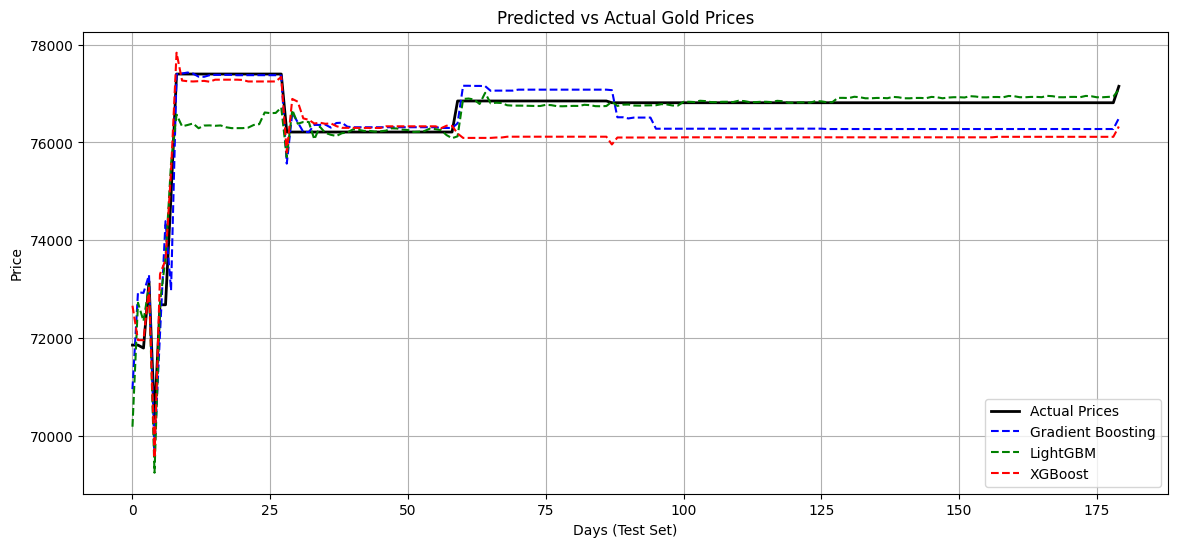

In [4]:
import matplotlib.pyplot as plt

# Get predictions from all models
y_pred_gbr = gbr.predict(X_test)
y_pred_lgbm = lgbm.predict(X_test)
y_pred_xgb = xgbm.predict(X_test)

#  Predicted vs Actual Prices
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Actual Prices', color='black', linewidth=2)
plt.plot(y_pred_gbr, label='Gradient Boosting', linestyle='--', color='blue')
plt.plot(y_pred_lgbm, label='LightGBM', linestyle='--', color='green')
plt.plot(y_pred_xgb, label='XGBoost', linestyle='--', color='red')
plt.title('Predicted vs Actual Gold Prices')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


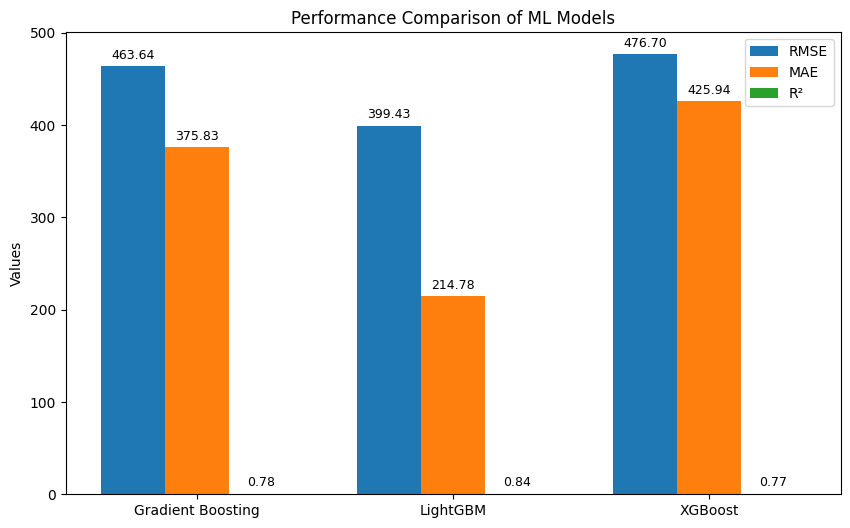

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Model metrics
models = ['Gradient Boosting', 'LightGBM', 'XGBoost']
rmse = [463.64, 399.43, 476.70]
mae  = [375.83, 214.78, 425.94]
r2   = [0.780, 0.837, 0.768]

x = np.arange(len(models))  # the label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))

# Plot RMSE, MAE, R²
bars1 = ax.bar(x - width, rmse, width, label='RMSE', color='#1f77b4')
bars2 = ax.bar(x, mae, width, label='MAE', color='#ff7f0e')
bars3 = ax.bar(x + width, r2, width, label='R²', color='#2ca02c')

# Add text labels
ax.set_ylabel('Values')
ax.set_title('Performance Comparison of ML Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Optional: add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()